### <p style="text-align: right;"> &#9989; Put your name here</p>

# __CMSE  201 &ndash; Fall 2021__

<img src="https://cmse.msu.edu/sites/_cmse/assets/Image/image002.jpg"
     alt="CMSE Logo"
     align="right" 
     height="100" 
     width="100" />
     
# Homework 4: Fitting data using NumPy and SciPy

## Goals

### By the end of the homework assignment you will have practiced:

1. Loading in data
2. Polynomial fitting using NumPy
3. Fitting curves using SciPy
4. Plotting data and the correspoding best-fit results
5. Calculating residuals when fitting a models to data

## Assignment instructions

Work through the following assignment, making sure to follow all of the directions and answer all of the questions.

**This assignment is due at 11:59pm on Friday, Nov 5th.** 

It should be uploaded to D2L in the approach "Homework" submission folder.  Submission instructions can be found at the end of the notebook as well.

## Grading

- Academic Integrity (1 pt)
- Part 1 (20 pts)
- Part 2 (24 pts)

**Total:** 45 pts


---
# Academic integrity statement (1 point)

In the markdown cell below, put your personal academic integrity statement (composed during the Day04 In-Class Assignment). By including this statement, you are confirming that the work you submit in the assignment is wholly your own.  

<font size=6 color="#009600">&#9998;</font> *Put your personal academic integrity statement here.*

---
## Part 1: Fitting Piece-wise Linear Functions to Data
In this problem, we will look at fitting more unusual functions to data.

### &#9989;&nbsp; Question 1.1: Setting up your Python modules (2 points)

In this homework, you will be mainly using Matplotlib, Pandas, NumPy, and SciPy's `curve_fit` function. Make sure to include all of the important `import` comments here.

In [ ]:
# Load needed modules here


In [1]:
### ANSWER ###

# NumPy
import numpy as np
# Pyplot
import matplotlib.pyplot as plt
%matplotlib inline
# curve_fit from SciPy
from scipy.optimize import curve_fit
#Pandas
import pandas as pd


### &#9989;&nbsp; Question 1.2: Generate and Plot Data (3 points)

Consider a function $y=f(x)$ such that $f(x) = 2x$ for $0 \leq x \leq 0.5$ and $f(x)=3-4x$ for $0.5 \leq x \leq 1$. Plot this function over 200 equispaced points ($x$) in the range of $x = $ 0 to 1 (end points included). Then, generate a noisy version of this function by adding Gaussian noise with mean zero and standard deviation 0.2 to all of the $y$ values from this function. Essentially, make $y_{noisy} = f(x) \, + $ Gaussian($x$). Plot the noisy data (versus $x$ values) in a new plot. Label all axes on the plots.

In [2]:
# Put your code here

Text(0, 0.5, 'Noisy Data')

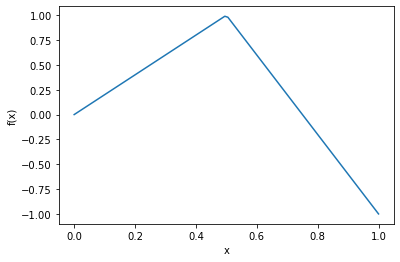

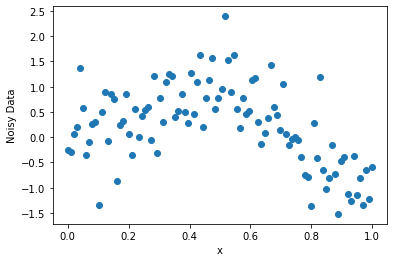

In [25]:
### ANSWER ###
# 1 point for setting up the function correctly, 1 point for plotting it, 1 point for adding noise correctly
# and 1 point for noisy data plot
import random
random.seed(10)
x = np.linspace(0,1,100)

y = np.zeros_like(x)
for i in range(x.size):
    if x[i] <= 0.5:
        y[i]=2*x[i]
    else:
        y[i]=3 - 4*x[i]
        
plt.figure()
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('f(x)')

y_noisy = y + np.random.normal(0, .5, x.size)
plt.figure()
plt.scatter(x,y_noisy)
plt.xlabel('x')
plt.ylabel('Noisy Data')


---
### &#9989;&nbsp; Question 1.3: Polynomial Fitting (4 points)

How would you use NumPy's `polyfit` function to fit a model like $f(x)$ (i.e., polynomial in two pieces) to the corrupted or noisy data? Explain your approach. Use only first order polynomials for this. Print all the fitted model parameters. Then use `poly1d` to help **plot the data together with the best fit model**. Include a legend to make it clear what information represents the data and what information represents the best fit. *Hint: You may fit more than one polynomial to this type of data.*

<font size=+3>&#9998;</font> *Put your explanation here.*

The parameters on the first half interval are [ 2.01522109 -0.03296637]
The parameters on the second half interval are [-4.93061802  3.70703668]


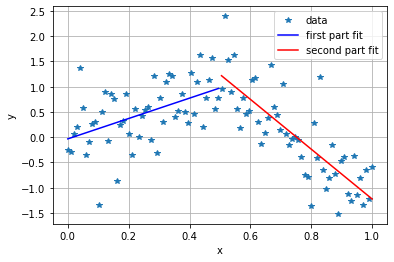

In [28]:
# Put your pseudocode and code here




The parameters on the first half interval are [ 2.01522109 -0.03296637]
The parameters on the second half interval are [-4.93061802  3.70703668]


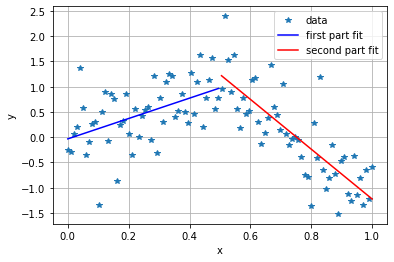

In [27]:
### ANSWER ###

# 1 pt for explanation of method
# 2 pts for doing poly fit on each segment and 1 pt for printing parameters
# 1 pt for plotting correctly.

#Break the data into two parts in [0,0.5] and (0.5,1] and fit different linear models for each part.

x1=x[x<=0.5]
y1=y_noisy[x<=0.5]

x2=x[x>0.5]
y2=y_noisy[x>0.5]

fit_poly_1 = np.polyfit( x1, y1, 1)
first_order_fit_1 = np.poly1d( fit_poly_1 )
print('The parameters on the first half interval are',fit_poly_1)

fit_poly_2 = np.polyfit( x2, y2, 1)
first_order_fit_2 = np.poly1d( fit_poly_2 )
print('The parameters on the second half interval are',fit_poly_2)

plt.plot( x, y_noisy, "*", label='data' )
plt.plot( x1, first_order_fit_1(x1), 'b',label="first part fit" )
plt.plot( x2,first_order_fit_2(x2),'r', label="second part fit" )
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend();


---
### &#9989;&nbsp; Question 1.4: Using Curve Fit for the data (5 points)

Write a function called `fitting_function` that takes the following arguments: $x$, $m_1$, $b_1$, $m_2$, $b_2$, where $x$ is a NumPy array and the rest are all floating point parameter values corresponding to the slopes of the lines/pieces and their intercepts. The function should return an array with values $f(x) = m_1*x + b_1$ when $0 \leq x \leq 0.5$ and $f(x) = m_2*x + b_2$ where $0.5 \leq x \leq 1$.

Use SciPy's `curve_fit` function to find the best fit model parameters for the corrupted data using your `fitting_function`. **Plot the data and the best fit. Label all axes and include a legend. Also print the resulting parameters.**

In [ ]:
# Put your pseudocode and code here

The best parameters are  [ 2.01522117 -0.0329664  -4.93061801  3.70703668]


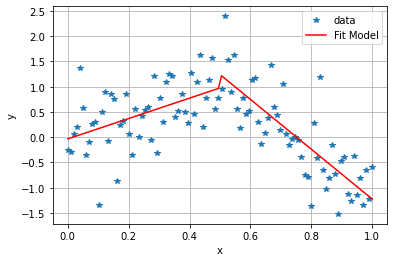

In [29]:
### ANSWER ###

# 3 pts for writing function correctly (getting function syntax right and including condition to choose between 2 cases)
# 2 pt for calling curve_fit correctly and getting parameters right
# 2 pts for plotting the data and best fit curve including labeling all axes.

def fitting_function(x, m1, b1, m2, b2):
    y = np.zeros_like(x)
    for i in range(x.size):
        if x[i] <= 0.5:
            y[i] = m1 * x[i] + b1
        else:
            y[i] = m2 * x[i] + b2
    return y

popt, pcov = curve_fit(fitting_function, x, y_noisy)
print('The best parameters are ', popt)

plt.plot( x, y_noisy, "*", label='data' )
plt.plot( x, fitting_function(x,popt[0],popt[1],popt[2],popt[3]), 'r',label="Fit Model" )
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend();

---
### &#9989;&nbsp; Question 1.5: Make the two lines meet on the boundary (6 point)
Notice that the two lines have different value when $x = 0.5$. To address this issue, we need to add one constrain:  the predicted $y$ from the left and right linear model at $x = 0.5$ should equal. Redefine your fitting_function to implement this constrain and use curve_fit function to find the best fit model parameters for data using the updated fitting_function2. **Plot the data and the best fit. Label all axes and include a legend.** (Hint: you can using the fact that the two lines meet at 0.5, which means m1 * 0.5 + b1 = m2 * 0.5 + b2 to solve b2. Now, you only need three parameters.)

<font size=+3>&#9998;</font> *Put your explanation here.*

The best parameters are  [ 2.41187971 -0.09775393 -4.53395934]


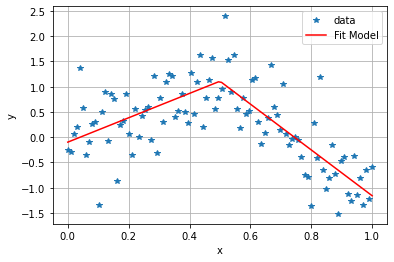

In [30]:
### ANSWER ###

# 3 pts for writing function correctly (getting function syntax right and including condition to choose between 2 cases)
# 2 pt for calling curve_fit correctly and getting parameters right
# 1 pts for plotting the data and best fit curve including labeling all axes.

#using m1 * 0.5 + b1 = m2 * 0.5 + b2 to solve b2
# b2 =  m1 * 0.5 + b1 - m2 * 0.5


def fitting_function2(x, m1, b1, m2):
    y = np.zeros_like(x)
    for i in range(x.size):
        if x[i] <= 0.5:
            y[i] = m1 * x[i] + b1
        else:
            y[i] = m2 * x[i] +  m1 * 0.5 + b1 - m2 * 0.5
    return y

popt, pcov = curve_fit(fitting_function2, x, y_noisy)
print('The best parameters are ', popt)

plt.plot( x, y_noisy, "*", label='data' )
plt.plot( x, fitting_function2(x,popt[0],popt[1],popt[2]), 'r',label="Fit Model" )
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend();

---
## Part 2: Fitting Models to Real Data
In this problem, we will look at fitting models to a real Wage data. You can download the [data.](https://drive.google.com/file/d/1DMSCODqMuapFHAl1jHnCy7yN-DOuKzQj/view?usp=sharing). You will use your model-fitting skills to see if you can find a good mathematical model for how the data behaves. 

### &#9989;&nbsp; Question 2.1: Reading and inspecting the data (2 points)

Read in the data using Pandas. Print out a few rows of the data as well as the summary statistics of the data (mean, standard deviation, etc.) to get a sense of the data.

In [ ]:
# Put your code here


In [429]:
### ANSWER ###
# 1 pt for reading correctly. 1pt for displaying a few rows, 1pt for using describe() for summary statistics
import pandas as pd
wage = pd.read_csv("Wage.csv")
wage.head(10)
wage.describe()

,Age,Wage
count,2918.000000,2918.000000
mean,42.317683,107.585245
std,11.621155,35.560037
min,18.000000,20.085537
25%,33.000000,84.334605
50%,42.000000,104.921507
75%,50.000000,127.115744
max,82.000000,614.329336


### &#9989;&nbsp; Question 2.2: Split the data into training and testing data. (3 points)

Randomly select 300 points as testing data (wage_test) and the rest as training data (wage_train). To enforce reproducibility, we utilize the random.seed function. The id for testing data is generated as follow, which you can use it to generate the testing and training data.


In [394]:
# Put your code here
import random
random.seed(6)
test_id = random.sample(range(2918), 300) 

test_id.sort()
test_id
# use test_id to generate wage_test and wage_train

[1,
 25,
 51,
 60,
 69,
 75,
 83,
 89,
 116,
 123,
 124,
 126,
 130,
 133,
 138,
 150,
 154,
 185,
 187,
 213,
 220,
 233,
 255,
 260,
 282,
 302,
 307,
 310,
 313,
 317,
 330,
 342,
 350,
 351,
 360,
 364,
 367,
 381,
 384,
 385,
 393,
 398,
 399,
 410,
 431,
 459,
 467,
 478,
 489,
 505,
 515,
 519,
 520,
 524,
 555,
 561,
 565,
 582,
 590,
 593,
 596,
 615,
 618,
 632,
 645,
 647,
 659,
 667,
 692,
 705,
 709,
 747,
 752,
 759,
 760,
 768,
 773,
 787,
 789,
 790,
 793,
 803,
 807,
 811,
 815,
 822,
 856,
 859,
 907,
 912,
 913,
 950,
 976,
 996,
 1003,
 1004,
 1022,
 1025,
 1028,
 1043,
 1049,
 1071,
 1086,
 1087,
 1088,
 1097,
 1102,
 1116,
 1122,
 1129,
 1132,
 1146,
 1153,
 1171,
 1184,
 1191,
 1192,
 1195,
 1242,
 1246,
 1252,
 1253,
 1279,
 1303,
 1308,
 1311,
 1324,
 1349,
 1363,
 1374,
 1377,
 1406,
 1435,
 1463,
 1475,
 1476,
 1478,
 1480,
 1482,
 1483,
 1488,
 1501,
 1517,
 1519,
 1521,
 1528,
 1534,
 1540,
 1545,
 1546,
 1555,
 1556,
 1590,
 1594,
 1629,
 1631,
 1636,
 167

In [395]:
### ANSWER ###
wage_train = wage.drop(test_id)
wage_test = wage.iloc[test_id]
wage_train = wage_train.sort_values(['Age'])
wage_test = wage_test.sort_values(['Age'])





### &#9989;&nbsp; Question 2.3: Polynomial fitting (4 points)

Using the NumPy `polyfit` function with degree of 3, fit the wage_train data with age being the predictor and wage being response. 
 Use `poly1d` to **plot the data together with the fit models**. The plot should label all axes and include legends to make clear what information represents the data and what information represents the fit. 

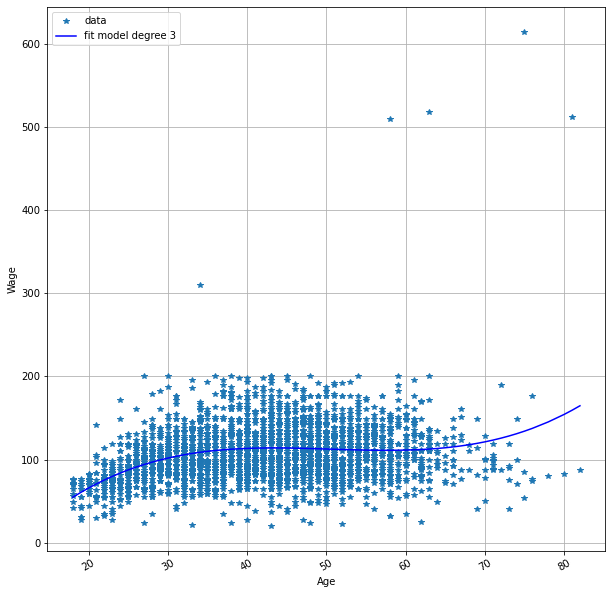

In [396]:
# Put your code here
wage_train_fit = np.polyfit(wage_train['Age'], wage_train['Wage'], 3)
train_fit = np.poly1d(wage_train_fit)

train_wage_predicted = train_fit(wage_train["Age"])

plt.figure(figsize = (10, 10))
plt.plot(wage_train['Age'], wage_train['Wage'], "*", label='data' )
plt.plot(wage_train['Age'], train_wage_predicted, 'b',label="fit model degree 3" )
plt.xticks(rotation=30)
plt.xlabel("Age")
plt.ylabel("Wage")
plt.grid()
plt.legend();




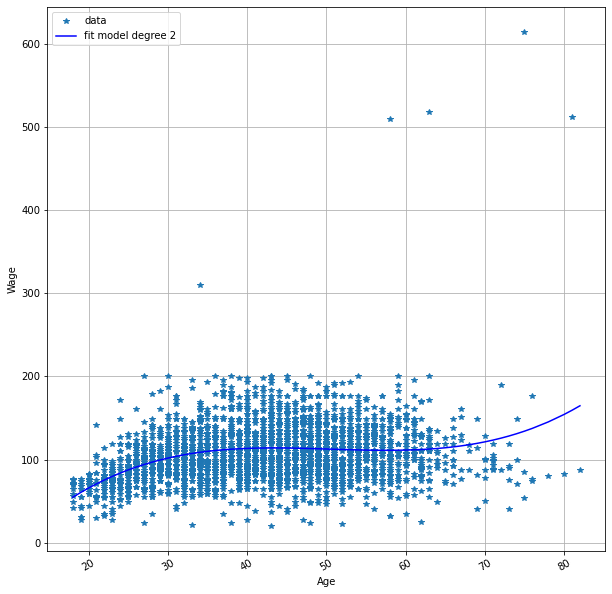

In [397]:
### ANSWER ###

# 2 pts for using polyfit 
#1 pts for the three plots including labeling axes and adding legends.


wage_train_fit = np.polyfit(wage_train['Age'], wage_train['Wage'], 3)
train_fit = np.poly1d(wage_train_fit)


plt.figure(figsize = (10, 10))
plt.plot(wage_train['Age'], wage_train['Wage'], "*", label='data' )
plt.plot(wage_train['Age'], train_fit(wage_train["Age"]), 'b',label="fit model degree 2" )
plt.xticks(rotation=30)
plt.xlabel("Age")
plt.ylabel("Wage")
plt.grid()
plt.legend();










<font size=+3>&#9998;</font> *Put your explanation here.*

### &#9989;&nbsp; Question 2.4: Detect outliers (7 points)

<img src="https://cdn1.byjus.com/wp-content/uploads/2020/10/Box-Plot-and-Whisker-Plot-1.png" alt="Moore" border="0" width=500px>

We can determine the quality of the data by computing the *residuals*, $r_i$, as the difference between each known data point $y_i$ and the *expected* $y$ value from the best fit model evaluated at $x_i$, i.e., $$r_i = y_i - f(x_i).$$  One way to identify outliers is to utilize the same principal as in boxplot where data points with residual less than $Q_1 - 1.5 (Q_3 - Q1)$ or gretter than $Q_3 + 1.5 (Q_3 - Q1)$ are treated as outliers, where $Q_1$ and $Q_3$ are the 25% and 75 % quantile of all the residuals. 

Use residuals to identify outliers, and remove them to make wage_train2. Using wage_wage2 to perform polyfit with degree 3. Use `poly1d` to **plot the data together with the fit models (blue line for fitted model using all the trained data and green line for fitted model for cleaned training data). Label outliers in red **. The plot should label all axes and include legends to make clear what information represents the data and what information represents the fit. 



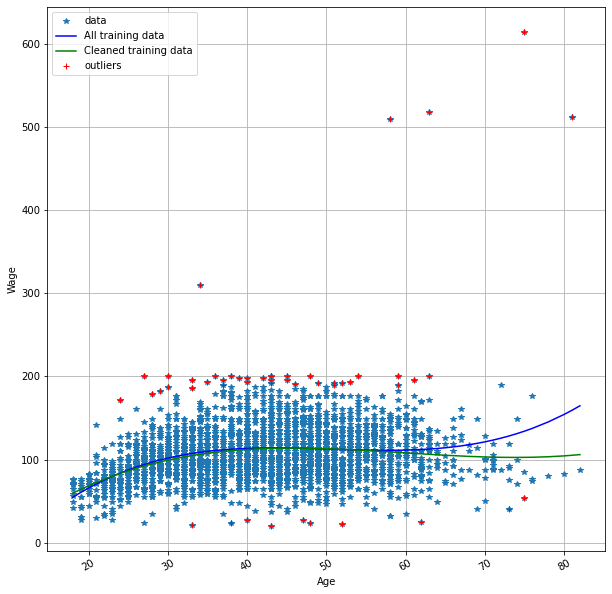

In [403]:
# Put your code here


<font size=+3>&#9998;</font> *Put your explanation here.*

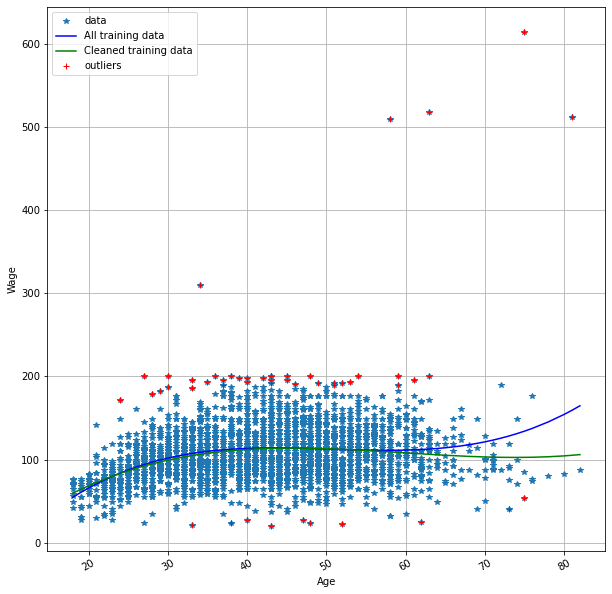

In [402]:
### ANSWER ###

# 4 pt for correctly find the outliers
# 1 pts for fitting the polyfit with cleaned training data

# 2 pts for plotting 

wage_train['Residuals'] = wage_train['Wage'] - train_wage_predicted
wage_train = pd.DataFrame(wage_train)
#plt.plot(wage_train['Age'], residuals, "*")
inter_quantile = residuals.quantile(0.75) - residuals.quantile(0.25)
upper_limit = 1.5 * inter_quantile + residuals.quantile(0.75)

lower_limit = -1.5 * inter_quantile + residuals.quantile(0.25)
mask = (lower_limit < wage_train['Residuals']) & (upper_limit > wage_train['Residuals'])
outlier_mask = (lower_limit > wage_train['Residuals']) | (upper_limit < wage_train['Residuals'])
wage_train2 = wage_train.loc[mask]
wage_train_outlier = wage_train.loc[outlier_mask]
(wage_train_outlier['Wage'])


wage_train2_fit = np.polyfit(wage_train2['Age'], wage_train2['Wage'], 3)
train_fit2 = np.poly1d(wage_train2_fit)



plt.figure(figsize = (10, 10))

plt.plot(wage_train['Age'], wage_train['Wage'], "*", label='data' )
plt.plot(wage_train['Age'], train_fit(wage_train["Age"]), 'b',label="All training data" )
plt.plot(wage_train['Age'], train_fit2(wage_train["Age"]), 'g',label="Cleaned training data" )


plt.plot(wage_train_outlier['Age'], wage_train_outlier['Wage'], '+r',label="outliers" )



plt.xticks(rotation=30)
plt.xlabel("Age")
plt.ylabel("Wage")
plt.grid()
plt.legend();




### &#9989;&nbsp; Question 2.5: Calculating the Test Error. (3 point)

The main goal for building a model is to make prediciton for data unseen. We will measure the prediction ability of our model using testing data which have never been seen by our model-fitting procedure. 

The residuals can be aggregated over all data points and summarized with the mean squared error $$MSE=\frac{1}{N}\sum_{i=1}^{N}r_i^2.$$ 

Calculate the   **mean squared error (MSEs)** for the models fitted using all or cleaned training data. Plot the testing data and the two fitted models together. 

Which one is better? Explain the reason using your own words.


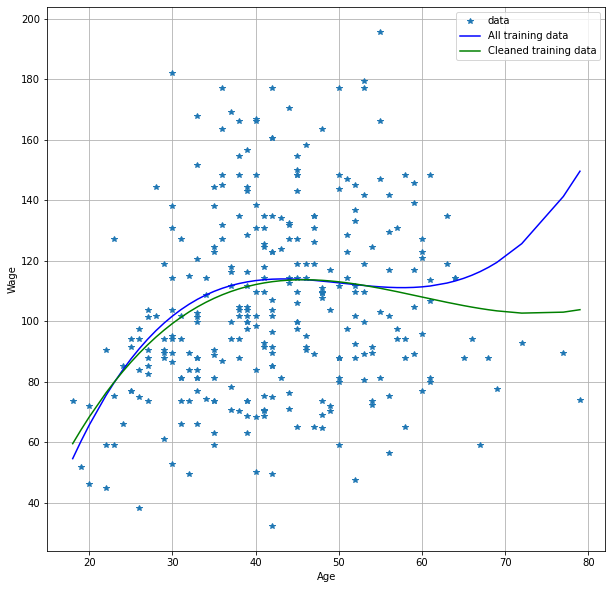

In [412]:
### Your Codes here




902.1117719323607 858.3009956250557


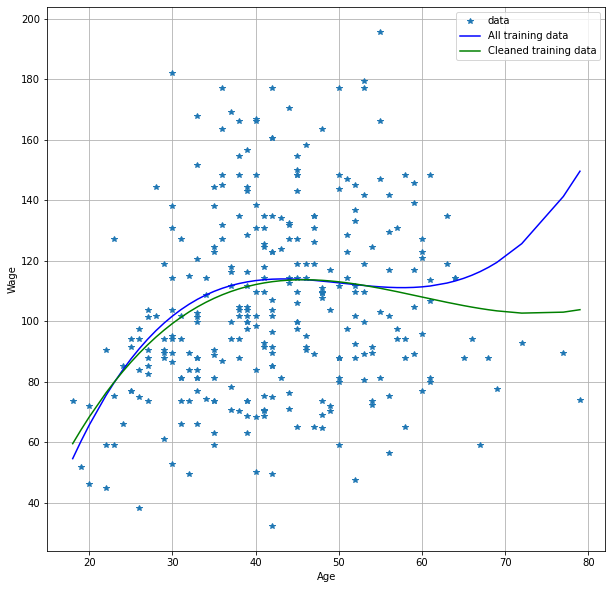

In [409]:
## ANSWER ###

wage_train_fit = np.polyfit(wage_train['Age'], wage_train['Wage'], 3)
train_fit = np.poly1d(wage_train_fit)

wage_train2_fit = np.polyfit(wage_train2['Age'], wage_train2['Wage'], 3)
train_fit2 = np.poly1d(wage_train2_fit)

Test_residuals = wage_test['Wage'] - train_fit(wage_test['Age'])
Test_residuals2 = wage_test['Wage'] - train_fit2(wage_test['Age'])

MSE = sum((Test_residuals)**2)/ len(wage_test['Wage'])
MSE2 = sum((Test_residuals2)**2)/ len(wage_test['Wage'])

print(MSE, MSE2)




plt.figure(figsize = (10, 10))

plt.plot(wage_test['Age'], wage_test['Wage'], "*", label='data' )
plt.plot(wage_test['Age'], train_fit(wage_test["Age"]), 'b',label="All training data" )
plt.plot(wage_test['Age'], train_fit2(wage_test["Age"]), 'g',label="Cleaned training data" )
plt.xlabel("Age")
plt.ylabel("Wage")
plt.grid()
plt.legend();


### &#9989;&nbsp; Question 2.6: Fitting the Cleaned Training Data with higher order Polynomial Model. (4 points)

Now, let's fit polynomial models with different order ($n = 1, 2, \ldots, 15$) to the cleaned training data. For each order, compute the MSE for the testing data to evaluate the prediction ability. ***Then make a plot of Testing data MSE vs. n.***. Which model will you choose?

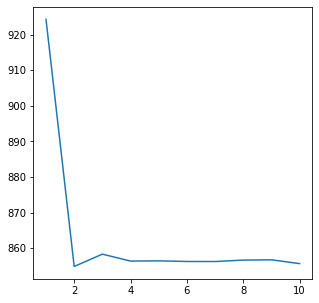

In [428]:
# Put your code here
plt.figure(figsize = (5, 5))
plt.plot(range(1, 11), result)



<font size=+3>&#9998;</font> *Put your explanation here.*

1
2
3
4
5
6
7
8
9
10


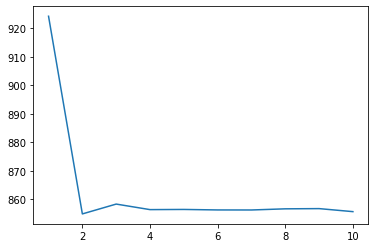

In [425]:
### ANSWER ###

# 2 pts for calculating the MSE for testing data
# 1 pt for plot n vs MSE
# 1 pt for picking the best model

result = []

for n in range(1, 11):
    wage_train2_fit = np.polyfit(wage_train2['Age'], wage_train2['Wage'], n)
    train_fit2 = np.poly1d(wage_train2_fit)
    Test_residuals2 = wage_test['Wage'] - train_fit2(wage_test['Age'])
    result.append(sum((Test_residuals2)**2)/ len(wage_test['Wage']))
    print(n)

plt.plot(range(1, 11), result)


In [ ]:
# Put your code here

---
## Assignment Wrap-up

Please fill out the following Google Form before you submit your assignment. **You must completely fill this out in order to receive credit for the assignment!**

**COMPLETE THIS SURVEY through [this link](https://forms.office.com/r/kGDrV361LB) or through cell below.**

### ANSWER

Instructors, you can access the responses to the survey [here](https://forms.office.com/Pages/DesignPage.aspx?fragment=FormId%3DMHEXIi9k2UGSEXQjetVofddd5T-Pwn1DlT6_yoCyuCFUQjRHUktCSEtQR0hLUVU0NkdWUlFSME9OMC4u%26Token%3Daafe169eea6d4c18b22d4401ef23158b).


In [2]:
from IPython.display import HTML
HTML(
"""
<iframe 
	src="https://forms.office.com/r/kGDrV361LB" 
	width="80%" 
	height="1200px" 
	frameborder="0" 
	marginheight="0" 
	marginwidth="0">
	Loading...
</iframe>
"""
)

---

### Congratulations, you're done!

Submit this assignment by uploading it to the course Desire2Learn web page.  
Go to the "Homework Assignments" section, find the appropriate submission folder link, and upload it there.


&#169; Copyright 2020, [Department of Computational Mathematics, Science and Engineering](https://cmse.msu.edu) at Michigan State University.